# W3D2 — Forward Pass in PyTorch — Lab

**Week 3 · Day 2 · Deep Learning & Neural Networks** · Lab

Nothing is trained today. Today you build the machine and check that it produces the numbers the
lecture produced — `[2.5, 1.0]` from the hidden layer, `1.5` at the output, `0.8176` after the
sigmoid — and then you look at what an untrained network's decision boundary is, so that tomorrow's
boundary means something when it curves.

Everything today is a PyTorch **tensor** — `torch.tensor`, `@`, `torch.clamp`, `torch.exp` — and
nothing else from the library: no `nn`, no autograd, no optimiser. Tensors are what every later week
is built on, so you meet them first on arithmetic you can check by hand.

Three things, in order:

- **The lecture's six weights, hard-coded.** Two inputs run through by hand, in three cells, printing
  the slide's numbers to four decimals. If your `0.8176` is `0.8175`, stop and find out why before
  you go any further.
- **The same thing as functions**: `init_params`, `forward`, and a `forward` that returns its
  intermediate values as well as its answer. You do not need the intermediates today. Tomorrow
  autograd computes its gradients by walking back through exactly these values, and when a gradient
  surprises you they are what you look at.
- **The untrained boundary**, drawn over `moons_toy`. It is a meaningless smear, and knowing what
  that looks like is the only way to recognise a trained one.

You leave with `forward_check.json`. Tomorrow autograd adds the backward pass to this exact network.

**Time budget:** ~115 minutes. Sections 1–2 are the lab; Section 3 is a stretch you may finish at home.

<div dir="rtl" align="right">

# الأسبوع ٣ اليوم ٢ — المرور الأمامي بـ PyTorch

**الأسبوع ٣ · اليوم ٢ · التعلّم العميق والشبكات العصبية** · معمل عملي

لا تدريب اليوم. اليوم تبني الآلة وتتحقّق أنها تُنتج الأرقام التي أنتجتها المحاضرة — `[2.5, 1.0]` من
الطبقة المخفية، و`1.5` عند المَخرج، و`0.8176` بعد الدالة السينية — ثم تنظر في حدّ القرار لشبكة غير
مُدرَّبة، ليكون لحدّ الغد معنى حين ينحني.

وكل شيء اليوم **تنسورات** (tensors) من PyTorch — `torch.tensor` و`@` و`torch.clamp` و`torch.exp` —
ولا شيء غيرها من المكتبة: لا `nn` ولا اشتقاق تلقائي (autograd) ولا مُحسِّن. فالتنسورات هي ما يُبنى عليه
كل أسبوع لاحق، فتلقاها أولًا على حساب تستطيع التحقّق منه بيدك.

وثلاثة أمور بالترتيب:

- **أوزان المحاضرة الستة مكتوبة يدويًا.** مدخلان يمرّان في ثلاث خلايا، وتُطبع أرقام الشريحة إلى أربع
  خانات عشرية. فإن كانت `0.8176` عندك `0.8175` فتوقّف واعرف السبب قبل أن تكمل.
- **الشيء نفسه على هيئة دوال**: `init_params` و`forward`، ودالة `forward` تُرجع قيمها الوسيطة مع
  جوابها. ولا تحتاج الوسيطة اليوم، لكن الاشتقاق التلقائي (autograd) غدًا يحسب اشتقاقاته بالرجوع عبر هذه
  القيم نفسها، وحين يفاجئك اشتقاق فهي ما تنظر فيه.
- **الحدّ غير المُدرَّب** مرسومًا على `moons_toy`. وهو لطخة بلا معنى، ومعرفة شكلها هي الطريق الوحيد
  للتعرّف على حدّ مُدرَّب.

ستخرج بملف `forward_check.json`. وغدًا يضيف الاشتقاق التلقائي المرور الخلفي إلى هذه الشبكة نفسها.

**الزمن المتوقّع:** نحو ١١٥ دقيقة. القسمان الأول والثاني هما المعمل، والقسم الثالث إضافي يمكن إكماله في المنزل.

</div>

> **This is your lab notebook.** Work through the hints — they tell you what to do and where
> to look, not what to type. Stuck for more than ten minutes on one task? Open the `_guided`
> version. That is not cheating; sitting stuck in silence is the only mistake. The full
> solution is released at the end of the day.

<div dir="rtl" align="right">

> **هذا دفتر المعمل الخاص بك.** اعمل وفق الإرشادات — فهي تخبرك بما يجب فعله وأين تبحث، لا بما
> تكتبه حرفيًا. إذا توقّفت أكثر من عشر دقائق عند مهمة واحدة فافتح نسخة `_guided`؛ هذا ليس غشًّا،
> والخطأ الوحيد هو أن تبقى متوقّفًا بصمت. ويُنشر الحل الكامل في نهاية اليوم.

</div>

## Learning objectives

By the end of this lab you can:

- Compute a forward pass through a two-layer network by hand and get the lecture's numbers to four
  decimals.
- Write `relu` and `sigmoid` in one line each, and say what each one is for.
- Initialise a network's parameters at any width and assert every shape before using them.
- Write a `forward` that returns both the output and the intermediate activations, and say why the
  intermediates are worth returning.
- Run 500 rows through in one matrix multiply and prove the batched answer for a row equals the
  single-row answer.
- Point at a hidden unit that ReLU clipped to exactly 0.0, and say what that unit contributed.
- Draw a decision boundary, and recognise an untrained one on sight.
- Count a network's weights and biases separately, and say why "26 parameters" is right and
  "26 weights" is not.

<div dir="rtl" align="right">

## أهداف التعلّم

بنهاية هذا المعمل ستكون قادرًا على:

- حساب مرور أمامي في شبكة ذات طبقتين بيدك والحصول على أرقام المحاضرة إلى أربع خانات عشرية.
- كتابة `relu` و`sigmoid` في سطر واحد لكل منهما، وبيان وظيفة كل واحدة.
- تهيئة معاملات الشبكة بأي عرض والتحقّق من كل شكل قبل استخدامه.
- كتابة `forward` تُرجع المُخرَج والتنشيطات الوسيطة معًا، وبيان لماذا تستحقّ الوسيطة الإرجاع.
- تمرير ٥٠٠ صف في ضرب مصفوفات واحد وإثبات أن جواب الدفعة لصفٍ يساوي جواب الصف المفرد.
- الإشارة إلى وحدة مخفية قصّتها ReLU إلى صفر تامّ، وبيان ما أسهمت به تلك الوحدة.
- رسم حدّ قرار، والتعرّف على حدّ غير مُدرَّب من النظرة الأولى.
- عدّ أوزان الشبكة وانحيازاتها كلًّا على حدة، وبيان لماذا «٢٦ معاملًا» صحيح و«٢٦ وزنًا» ليس صحيحًا.

</div>


## About the data

**Dataset:** `moons_toy` — 500 rows × 3 columns, generated for this course with
`sklearn.datasets.make_moons(noise=0.2, random_state=42)`, CC0

Two columns, `x1` and `x2`, and a binary `label`. One row is one point in a plane. The two classes
are two interleaving half-moons, which matters for three reasons:

- **It is not linearly separable.** A logistic regression scores about 0.86 on it. A curved boundary
  scores about 0.98. That 12-point gap is what the rest of this week is for.
- **It is two-dimensional**, so a decision boundary can be *drawn*. From tomorrow you will be looking
  at pictures of what your network learned, not just at a number.
- **It is 500 rows**, so a from-scratch PyTorch network trains on it in about a second. You will train
  it dozens of times this week.

**Watch out:** the noise is 0.2, which means the moons genuinely overlap and perfect accuracy is
**impossible**. If you ever see 1.00 on this data, you have a bug or you are scoring the rows you
fitted on. About 0.98 is the ceiling.

<div dir="rtl" align="right">

## عن البيانات

**مجموعة البيانات:** `moons_toy` — ٥٠٠ صف × ٣ أعمدة، مُولَّدة لهذه الدورة بـ
`sklearn.datasets.make_moons(noise=0.2, random_state=42)`، رخصة CC0

عمودان `x1` و`x2`، وتصنيف ثنائي `label`. والصف الواحد نقطة في مستوى. والفئتان هلالان متداخلان، وهذا
مهمّ لثلاثة أسباب:

- **غير قابلة للفصل خطيًا.** فالانحدار اللوجستي يسجّل نحو ٠٫٨٦ عليها، والحدّ المنحني يسجّل نحو ٠٫٩٨.
  وهذه الفجوة المقدارها ١٢ نقطة هي ما تبقّى من هذا الأسبوع لأجله.
- **ثنائية البعد**، فيمكن **رسم** حدّ القرار. ومن الغد ستنظر في صور لما تعلّمته شبكتك لا في رقم فقط.
- **٥٠٠ صف**، فتتدرّب عليها شبكة مكتوبة من الصفر بـ PyTorch في نحو ثانية. وستدرّبها عشرات المرات هذا
  الأسبوع.

**انتبه:** الضوضاء ٠٫٢، ومعناها أن الهلالين متداخلان فعلًا وأن الدقة الكاملة **مستحيلة**. فإن رأيت
١٫٠٠ على هذه البيانات فعندك عيب، أو أنك تقيس الصفوف التي تدرّبت عليها. والسقف نحو ٠٫٩٨.

</div>


## Setup

Run the cell below first. It loads the data and fixes the architecture the whole week shares: two
inputs, eight hidden units, one output.

Eight, not the lecture's two. The lecture used two hidden units because six weights fit on a slide
and you can multiply them in your head — and you will reproduce that exact network in the warm-up.
But two ReLU units can only bend a boundary twice, which is not enough to wrap around a moon; at
eight units tomorrow's trained network reaches 0.98 instead of 0.86. Same code, same arithmetic, one
number changed.

One line in it is worth noticing: `torch.set_default_dtype(torch.float64)`. PyTorch's default is
32-bit floats, which carry about seven significant digits — plenty for training, and not enough for
today's four-decimal checks or tomorrow's gradient check to `1e-6`. Every tensor this week is 64-bit.

<div dir="rtl" align="right">

## الإعداد

شغّل الخليّة أدناه أولًا. تُحمّل البيانات وتُثبّت المعمارية التي يشترك فيها الأسبوع كله: مدخلان وثماني
وحدات مخفية ومَخرج واحد.

ثمانية لا اثنتان كما في المحاضرة. فالمحاضرة استخدمت وحدتين مخفيتين لأن ستة أوزان تُوضَع في شريحة
وتستطيع ضربها في رأسك — وستُعيد إنتاج تلك الشبكة نفسها في التهيئة. لكن وحدتَي ReLU لا تستطيعان ثني
الحدّ إلا مرتين، وهذا لا يكفي للالتفاف حول هلال؛ وبثماني وحدات تصل شبكة الغد المُدرَّبة إلى ٠٫٩٨ بدلًا
من ٠٫٨٦. الشيفرة نفسها والحساب نفسه ورقم واحد تغيّر.

وفيها سطر يستحقّ الانتباه: `torch.set_default_dtype(torch.float64)`. فافتراض PyTorch فواصل عائمة
بـ ٣٢ بتًا تحمل نحو سبع خانات معنوية — وهذا يكفي للتدريب ولا يكفي لفحوص اليوم بأربع خانات عشرية ولا
لفحص الاشتقاق غدًا إلى `1e-6`. فكل تنسور هذا الأسبوع بـ ٦٤ بتًا.

</div>


In [1]:
# === AIEP portable setup — works locally (Miniconda + uv) and on Google Colab ===============
try:
    import aiep
except ImportError:
    import subprocess, sys
    from pathlib import Path
    _local = next((p / "shared" for p in [Path.cwd(), *Path.cwd().parents]
                   if (p / "shared" / "aiep").is_dir()), None)
    if _local:
        sys.path.insert(0, str(_local))
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               "git+https://github.com/0xRush/AIEP_Olo_student.git#subdirectory=shared"])
    import aiep

from aiep.env import ensure, seed_everything, versions
from aiep.data import get_dataset
from aiep.paths import ARTEFACT_DIR
from aiep.checks import check, report

ensure("torch", "scikit-learn", "matplotlib", "pyarrow")
seed_everything(42)

import json
import math

import pandas as pd
import matplotlib.pyplot as plt
import torch

from aiep.viz import use_course_style, PALETTE
use_course_style()

# 64-bit floats, so the slide's numbers come out to the last decimal. PyTorch defaults to
# 32-bit, which is enough for training and not enough for checking arithmetic by hand.
torch.set_default_dtype(torch.float64)

moons = pd.read_parquet(get_dataset("moons_toy"))
X = torch.tensor(moons[["x1", "x2"]].to_numpy())                                  # (500, 2)
y = torch.tensor(moons["label"].to_numpy(), dtype=torch.float64).reshape(-1, 1)   # (500, 1) — a column

# The architecture for the rest of the week. Two in, eight hidden, one out.
N_IN, N_HIDDEN, N_OUT = 2, 8, 1
SEED = 42

print(f"X {tuple(X.shape)} | y {tuple(y.shape)} | positive class {y.mean():.1%}")
print(f"x1 range [{X[:, 0].min():.2f}, {X[:, 0].max():.2f}] | "
      f"x2 range [{X[:, 1].min():.2f}, {X[:, 1].max():.2f}]")
print("\n", versions())

📁 moons_toy: using cached file at C:\Users\user\Documents\GitHub\AIEP_Olo_student\shared\data_cache\moons_toy.parquet
X (500, 2) | y (500, 1) | positive class 50.0%
x1 range [-1.48, 2.48] | x2 range [-0.99, 1.50]

 python 3.12.14 | numpy 2.0.2 | pandas 3.0.5 | scikit-learn 1.9.0 | torch 2.13.0+cpu | transformers 5.15.1


## Section 1 — Warm-up: the lecture's six weights  (≈25 min)

Everything in this section already works.

These are the numbers from the morning, hard-coded:

| | | |
|---|---|---|
| `W1` | `[[0.5, -0.5], [1.0, 0.5]]` | two inputs → two hidden units |
| `b1` | `[0.0, 0.5]` | one bias per hidden unit |
| `W2` | `[1.0, -1.0]` | two hidden units → one output |
| `b2` | `0.0` | one bias at the output |

**The next three cells must print the slide's numbers exactly**: `[2.5, 1.0]`, then `1.5`, then
`0.8176`. Not approximately. If a digit is off, the arithmetic is wrong somewhere and everything you
build on top of it will be wrong in the same way, silently.

<div dir="rtl" align="right">

## القسم الأول — التهيئة: أوزان المحاضرة الستة (نحو ٢٥ دقيقة)

كل ما في هذا القسم يعمل أصلًا.

وهذه أرقام الصباح مكتوبة يدويًا:

| | | |
|---|---|---|
| `W1` | `[[0.5, -0.5], [1.0, 0.5]]` | مدخلان ← وحدتان مخفيتان |
| `b1` | `[0.0, 0.5]` | انحياز واحد لكل وحدة مخفية |
| `W2` | `[1.0, -1.0]` | وحدتان مخفيتان ← مَخرج واحد |
| `b2` | `0.0` | انحياز واحد عند المَخرج |

**وعلى الخلايا الثلاث التالية أن تطبع أرقام الشريحة بالضبط**: `[2.5, 1.0]` ثم `1.5` ثم `0.8176`. لا
تقريبًا. فإن اختلفت خانة فالحساب خطأ في مكان ما، وكل ما تبنيه فوقه سيكون خطأً بالطريقة نفسها وبصمت.

</div>


In [2]:
LECTURE = {
    "W1": torch.tensor([[0.5, -0.5],
                        [1.0,  0.5]]),
    "b1": torch.tensor([0.0, 0.5]),
    "W2": torch.tensor([[1.0], [-1.0]]),
    "b2": torch.tensor([0.0]),
}


def relu(z):
    """Pass positives through unchanged; replace negatives with zero."""
    return torch.clamp(z, min=0)


def sigmoid(z):
    """Squash any real number into (0, 1). The output activation for one yes/no answer."""
    return 1 / (1 + torch.exp(-z))


x = torch.tensor([1.0, 2.0])

z1 = x @ LECTURE["W1"] + LECTURE["b1"]
print(f"pre-activation   z1 = {z1.tolist()}")
print(f"hidden neuron 1: 1(0.5) + 2(1.0) + 0   = {z1[0].item()}")
print(f"hidden neuron 2: 1(-0.5) + 2(0.5) + 0.5 = {z1[1].item()}")

pre-activation   z1 = [2.5, 1.0]
hidden neuron 1: 1(0.5) + 2(1.0) + 0   = 2.5
hidden neuron 2: 1(-0.5) + 2(0.5) + 0.5 = 1.0


In [3]:
a1 = relu(z1)
print(f"after ReLU       a1 = {a1.tolist()}      <- the slide's [2.5, 1.0]")
print(f"nothing was clipped: both pre-activations were already positive")

z2 = a1 @ LECTURE["W2"] + LECTURE["b2"]
print(f"\noutput layer:    2.5(1.0) + 1.0(-1.0) + 0 = {z2[0].item()}")
print(f"the logit        z2 = {z2[0]:.4f}   <- a raw score, not a probability")

after ReLU       a1 = [2.5, 1.0]      <- the slide's [2.5, 1.0]
nothing was clipped: both pre-activations were already positive

output layer:    2.5(1.0) + 1.0(-1.0) + 0 = 1.5
the logit        z2 = 1.5000   <- a raw score, not a probability


In [4]:
out = sigmoid(z2)
print(f"sigmoid(1.5)     = {out[0]:.4f}      <- the slide's 0.8176")
print()
print(f"matches the slide to 4 decimals: {math.isclose(out[0].item(), 0.8176, abs_tol=5e-5)}")

# Keep these three, checked against the slide, for the artefact at the end.
HAND_A1 = a1.clone()
HAND_LOGIT = z2[0].item()
HAND_OUTPUT = out[0].item()

sigmoid(1.5)     = 0.8176      <- the slide's 0.8176

matches the slide to 4 decimals: True


### Task 1.1 — the same network, a different input

Nothing has been retrained. Same six weights, and now `x = [3, -1]`.

Hidden neuron 1: `3(0.5) + (-1)(1.0) + 0 = 0.5`. Hidden neuron 2: `3(-0.5) + (-1)(0.5) + 0.5 = -1.5`.

ReLU sees `-1.5` and outputs exactly `0`. Not a small number — zero. That unit contributes **nothing
at all** to the output for this input, and its weight to the output layer is multiplied by zero.

For the previous input it contributed 1.0. Which units are silent changes row by row, and that is
where a network's flexibility comes from. This is the entire reason a non-linearity exists, and the
cell below is it happening on real numbers.

<div dir="rtl" align="right">

### المهمة ١٫١ — الشبكة نفسها، مُدخل آخر

لم يُعَد تدريب شيء. الأوزان الستة نفسها، والآن `x = [3, -1]`.

العصبون المخفي الأول: `3(0.5) + (-1)(1.0) + 0 = 0.5`. والثاني: `3(-0.5) + (-1)(0.5) + 0.5 = -1.5`.

فترى ReLU القيمة `-1.5` وتُخرج صفرًا تامًّا. ليس رقمًا صغيرًا بل صفرًا. وتلك الوحدة لا تسهم **بشيء
إطلاقًا** في المَخرج لهذا المُدخل، ويُضرَب وزنها إلى طبقة المَخرج في صفر.

وفي المُدخل السابق أسهمت بـ ١٫٠. فأي الوحدات ساكتة يتغيّر من صفّ إلى صفّ، ومن هنا تأتي مرونة الشبكة.
وهذا هو سبب وجود اللاخطية كله، والخليّة أدناه هي ذلك يحدث على أرقام حقيقية.

</div>


In [5]:
for point in (torch.tensor([1.0, 2.0]), torch.tensor([3.0, -1.0]), torch.tensor([1.0, -2.0])):
    pre = point @ LECTURE["W1"] + LECTURE["b1"]
    post = relu(pre)
    silenced = int((post == 0).sum())
    logit = (post @ LECTURE["W2"] + LECTURE["b2"])[0]
    print(f"x = {str(point.tolist()):<12} pre {pre.round(decimals=2).tolist()} -> "
          f"post {post.round(decimals=2).tolist()}"
          f"   {silenced} unit(s) silent   sigmoid -> {sigmoid(logit):.4f}")

x = [1.0, 2.0]   pre [2.5, 1.0] -> post [2.5, 1.0]   0 unit(s) silent   sigmoid -> 0.8176
x = [3.0, -1.0]  pre [0.5, -1.5] -> post [0.5, 0.0]   1 unit(s) silent   sigmoid -> 0.6225
x = [1.0, -2.0]  pre [-1.5, -1.0] -> post [0.0, 0.0]   2 unit(s) silent   sigmoid -> 0.5000


Read the third row. `x = [1, -2]` gives pre-activations `[-1.5, -1.0]` and **both** units are
silenced — the hidden layer outputs `[0, 0]`, the logit is `b2` and nothing else, and the network
answers 0.5000 because it has nothing to say about that point at all.

That is a dead layer, for one input, and you will meet it again on Sunday as a diagnosis: a flat loss
curve where every activation is zero and no learning rate can help.

<div dir="rtl" align="right">

اقرأ الصفّ الثالث. `x = [1, -2]` يعطي ما قبل التنشيط `[-1.5, -1.0]`، و**كلتا** الوحدتين تُسكَتان —
فتُخرج الطبقة المخفية `[0, 0]`، ويكون الـ logit هو `b2` ولا شيء غيره، وتجيب الشبكة ٠٫٥٠٠٠ لأنه لا شيء
عندها تقوله عن تلك النقطة إطلاقًا.

وهذه طبقة ميتة لمُدخل واحد، وستلقاها مرة أخرى يوم الأحد كتشخيص: منحنى خسارة مسطّح تكون فيه كل
التنشيطات أصفارًا ولا يُفيد فيه أي معدّل تعلّم.

</div>


## Section 2 — Core: five tasks  (≈60 min)

1. `init_params(n_in, n_hidden, n_out)` — random weights, a fixed seed, every shape asserted.
2. `forward(params, X)` — returns the output **and** the intermediates.
3. Batch all 500 rows through at once, and prove row 0 agrees with the single-row answer.
4. Count the parameters, and count weights and biases separately.
5. Draw the untrained network's decision boundary over the moons.

<div dir="rtl" align="right">

## القسم الثاني — الأساسي: خمس مهام (نحو ٦٠ دقيقة)

١. `init_params(n_in, n_hidden, n_out)` — أوزان عشوائية وبذرة ثابتة والتحقّق من كل شكل.
٢. `forward(params, X)` — تُرجع المُخرَج **والقيم الوسيطة**.
٣. مرِّر الصفوف الخمسمئة كلها مرة واحدة، وأثبِت أن الصفّ صفرًا يوافق جواب الصف المفرد.
٤. عُدّ المعاملات، وعُدّ الأوزان والانحيازات كلًّا على حدة.
٥. ارسم حدّ قرار الشبكة غير المُدرَّبة على الهلالين.

</div>


### Task 2.1 — initialise it, and assert the shapes

Six hard-coded weights got you through the warm-up. The network you train tomorrow has 33, and you
are not typing those.

Two rules for the initial values:

- **Random, not zero.** If every hidden unit starts identical, every unit receives the same gradient
  and stays identical forever. You would have paid for eight units and trained one.
- **Small, and scaled to the layer's width.** The standard choice for a ReLU layer is a normal
  distribution with standard deviation `sqrt(2 / n_inputs)` — "He initialisation". Too large and the
  sigmoid saturates on the first pass; too small and the signal dies on the way through. You will
  measure why this matters on Sunday.

Biases start at zero. There is no symmetry to break in a bias.

Then assert every shape, before anything uses them. A shape error caught here costs you one line; the
same error caught inside a training loop costs you the afternoon.

<div dir="rtl" align="right">

### المهمة ٢٫١ — هيّئها وتحقّق من الأشكال

أوصلتك ستة أوزان مكتوبة يدويًا إلى نهاية التهيئة. والشبكة التي تدرّبها غدًا فيها ٣٣ وزنًا، ولن تكتبها.

وقاعدتان للقيم الابتدائية:

- **عشوائية لا أصفار.** فإن بدأت كل وحدة مخفية متطابقة مع غيرها، تلقّت كل وحدة الاشتقاق نفسه وبقيت
  متطابقة إلى الأبد. فتكون دفعت ثمن ثماني وحدات ودرّبت واحدة.
- **صغيرة ومُقيَّسة بعرض الطبقة.** والاختيار المتعارف عليه لطبقة ReLU هو توزيع طبيعي بانحراف معياري
  `sqrt(2 / n_inputs)` ويُسمّى تهيئة He. فإن كبرت تشبّعت الدالة السينية من أول مرور، وإن صغرت مات
  الإشارة في الطريق. وستقيس سبب أهمية هذا يوم الأحد.

والانحيازات تبدأ من الصفر، فلا تناظر يُكسَر في انحياز.

ثم تحقّق من كل شكل قبل أن يستخدمها شيء. فخطأ شكل تُمسكه هنا يكلّفك سطرًا، وخطأ الشكل نفسه تُمسكه داخل
حلقة تدريب يكلّفك بعد الظهر كله.

</div>


In [6]:
# ────────────────────────────────────────────────────────────────────
# 1) Make a fresh torch.Generator().manual_seed(seed) and pass it to every random
#    call, so the same seed always gives the same weights. Do not use
#    torch.manual_seed — that seeds a global state every other cell shares.
# 2) W1 is (n_in, n_hidden) and W2 is (n_hidden, n_out). The shape rule from the
#    lecture: (batch, in) x (in, out) -> (batch, out).
# 3) torch.randn draws from a standard normal; multiply by sqrt(2 / fan_in), where
#    fan_in is the number of inputs to THAT layer. Biases are torch.zeros.
# 4) Return a dict with keys W1, b1, W2, b2 — tomorrow's lab expects exactly
#    those names.
# Search: "torch Generator manual_seed randn He initialisation shape"
# https://pytorch.org/docs/stable/generated/torch.randn.html
#
# ١) أنشئ `torch.Generator().manual_seed(seed)` جديدًا ومرّره إلى كل نداء عشوائي، لتعطي
#    البذرة نفسها الأوزان نفسها دائمًا. ولا تستخدم `torch.manual_seed`، فهي تبذر حالة
#    عامة تشترك فيها كل الخلايا الأخرى.
# ٢) شكل `W1` هو (`n_in`, `n_hidden`) وشكل `W2` هو (`n_hidden`, `n_out`). وقاعدة
#    الأشكال من المحاضرة: (batch, in) × (in, out) ← (batch, out).
# ٣) `torch.randn` يسحب من توزيع طبيعي معياري؛ فاضربه في `sqrt(2 / fan_in)`، حيث
#    `fan_in` عدد مدخلات **تلك** الطبقة. والانحيازات `torch.zeros`.
# ٤) أرجِع `dict` بمفاتيح `W1` و`b1` و`W2` و`b2` — فمعمل الغد يتوقّع هذه الأسماء
#    بالضبط.
# ابحث عن: "torch Generator manual_seed randn He initialisation shape"
# ────────────────────────────────────────────────────────────────────

# TODO: Write init_params: He-scaled random weights, zero biases, a fixed seed.
# مهمة: اكتب `init_params`: أوزان عشوائية بمقياس He، وانحيازات صفرية، وبذرة ثابتة.
def init_params(n_in, n_hidden, n_out, seed=42):
    g = torch.Generator().manual_seed(seed)

    W1 = torch.randn(n_in, n_hidden, generator=g) * math.sqrt(2 / n_in)
    b1 = torch.zeros(n_hidden)

    W2 = torch.randn(n_hidden, n_out, generator=g) * math.sqrt(2 / n_hidden)
    b2 = torch.zeros(n_out)

    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}
params = init_params(N_IN, N_HIDDEN, N_OUT)
expected_shapes = {"W1": (N_IN, N_HIDDEN), "b1": (N_HIDDEN,),
                   "W2": (N_HIDDEN, N_OUT), "b2": (N_OUT,)}
for name, shape in expected_shapes.items():
    assert params[name].shape == shape, (
        f"{name} should be {shape}, got {tuple(params[name].shape)}")
    print(f"{name}: {str(tuple(params[name].shape)):<8} ok")
print(f"\nb1 is all zeros: {bool(torch.all(params['b1'] == 0))}")
print(f"W1 std: {params['W1'].std():.3f}  (He target for 2 inputs: "
      f"{math.sqrt(2 / N_IN):.3f})")
print(f"same seed gives the same weights: "
      f"{torch.equal(params['W1'], init_params(N_IN, N_HIDDEN, N_OUT)['W1'])}")

W1: (2, 8)   ok
b1: (8,)     ok
W2: (8, 1)   ok
b2: (1,)     ok

b1 is all zeros: True
W1 std: 0.989  (He target for 2 inputs: 1.000)
same seed gives the same weights: True


### Task 2.2 — `forward`, returning what tomorrow needs

The function itself is two lines of arithmetic. What matters is what it gives back.

Return a `(output, cache)` pair, where the cache holds `z1`, `a1` and `z2` — the values computed on
the way through. You will not use `z1` today. Tomorrow autograd computes every gradient by walking
back through exactly these values — `z1` is how it knows which units ReLU clipped, `a1` is what the
output layer's gradients are made of — and when one of its answers surprises you, the cache is how
you look at what it saw. A `forward` that returns only its answer has thrown that away.

This is the one piece of advice in this lab that is about software rather than about networks:
**compute it once, return it, decide later whether you needed it.**

<div dir="rtl" align="right">

### المهمة ٢٫٢ — `forward` تُرجع ما يحتاجه الغد

الدالة نفسها سطران من الحساب. والمهمّ هو ما تُرجعه.

أرجِع زوجًا `(output, cache)`، حيث تحمل الذاكرة `z1` و`a1` و`z2` — أي القيم المحسوبة في الطريق. ولن
تستخدم `z1` اليوم. لكن الاشتقاق التلقائي (autograd) غدًا يحسب كل اشتقاق بالرجوع عبر هذه القيم نفسها
— فبـ `z1` يعرف أي الوحدات قصّتها ReLU، ومن `a1` تُصنع اشتقاقات طبقة المَخرج — وحين يفاجئك أحد أجوبته
فالذاكرة هي طريقك إلى رؤية ما رآه. والدالة التي تُرجع جوابها وحده تكون رمت ذلك.

وهذه هي النصيحة الوحيدة في هذا المعمل التي تخصّ البرمجة لا الشبكات: **احسبه مرة، وأرجِعه، وقرّر
لاحقًا هل احتجته.**

</div>


In [7]:
# ────────────────────────────────────────────────────────────────────
# 1) Four steps, in the order the warm-up did them by hand: the first layer's
#    weighted sum plus its bias, ReLU on that, the second layer's weighted sum
#    plus its bias, then the output activation.
# 2) Name each intermediate as you go — the pre-activation, the post-ReLU
#    activation, and the logit. Return the output AND a dict of those three.
#    You do not need the first one today; tomorrow you will want all three.
# 3) Do not reshape anything inside forward. If a shape is wrong it is wrong at
#    the call site, and a reshape here hides it.
# Search: "torch matmul @ operator broadcasting bias"
# https://pytorch.org/docs/stable/generated/torch.matmul.html
#
# ١) أربع خطوات بالترتيب الذي فعلته التهيئة يدويًا: المجموع الموزون للطبقة الأولى
#    مع انحيازها، ثم ReLU عليه، ثم المجموع الموزون للطبقة الثانية مع انحيازها، ثم
#    تنشيط المَخرج.
# ٢) سمِّ كل قيمة وسيطة وأنت تمضي: ما قبل التنشيط، والتنشيط بعد ReLU، والـ logit.
#    وأرجِع المُخرَج **و**قاموسًا بهذه الثلاث. ولا تحتاج الأولى اليوم، لكنك ستريد
#    الثلاث غدًا.
# ٣) لا تُعِد تشكيل شيء داخل `forward`. فإن كان شكلٌ خطأً فهو خطأ عند موضع النداء،
#    وإعادة التشكيل هنا تُخفيه.
# ابحث عن: "torch matmul @ operator broadcasting bias"
# ────────────────────────────────────────────────────────────────────

# TODO: Write forward(params, X) -> (output, cache) with z1, a1 and z2 in the cache.
# مهمة: اكتب `forward(params, X)` ← `(output, cache)` وفي الذاكرة `z1` و`a1` و`z2`.
def forward(params, X):
    z1 = X @ params["W1"] + params["b1"]
    a1 = relu(z1)
    z2 = a1 @ params["W2"] + params["b2"]
    output = sigmoid(z2)

    cache = {
        "z1": z1,
        "a1": a1,
        "z2": z2
    }

    return output, cache
check_out, check_cache = forward(LECTURE, torch.tensor([[1.0, 2.0]]))
print(f"a1 through forward(): {check_cache['a1'][0].tolist()}   "
      f"(hand: {HAND_A1.tolist()})")
print(f"logit:                {check_cache['z2'][0, 0]:.4f}   "
      f"(hand: {HAND_LOGIT:.4f})")
print(f"output:               {check_out[0, 0]:.4f}   "
      f"(hand: {HAND_OUTPUT:.4f})")
print(f"\ncache keys: {sorted(check_cache)}")

a1 through forward(): [2.5, 1.0]   (hand: [2.5, 1.0])
logit:                1.5000   (hand: 1.5000)
output:               0.8176   (hand: 0.8176)

cache keys: ['a1', 'z1', 'z2']


### Task 2.3 — 500 rows in one multiply

The warm-up ran one point at a time. Now run all 500 at once — the same function, a `(500, 2)` array
instead of a `(1, 2)` one, and no loop anywhere.

`(500, 2) × (2, 8) → (500, 8)`. The inner pair meets and disappears; the outer pair is the answer's
shape. The bias `(8,)` is added to all 500 rows by broadcasting, which is W2D1's rule doing real work.

Then the check that matters: **the batched result for row 0 must equal the single-row result for row
0**, to floating-point exactness. If it does not, you have a broadcasting bug, and it will not
announce itself — it will quietly train a slightly wrong network.

<div dir="rtl" align="right">

### المهمة ٢٫٣ — خمسمئة صف في ضرب واحد

مرّرت التهيئة نقطة واحدة في كل مرة. ومرّر الآن الخمسمئة كلها مرة واحدة — الدالة نفسها ومصفوفة
`(500, 2)` بدلًا من `(1, 2)`، وبلا أي حلقة.

`(500, 2) × (2, 8) ← (500, 8)`. فيلتقي الزوج الداخلي ويختفي، والزوج الخارجي هو شكل الجواب. ويُضاف
الانحياز `(8,)` إلى الصفوف الخمسمئة كلها بالبثّ (broadcasting)، وهي قاعدة الأسبوع الثاني اليوم الأول
تعمل عملًا حقيقيًا.

ثم الفحص المهمّ: **يجب أن يساوي ناتج الدفعة للصفّ صفرًا ناتج الصفّ المفرد للصفّ صفرًا** مساواةً تامة
في الفواصل العائمة. فإن لم يساوِه فعندك عيب بثّ، ولن يُعلن عن نفسه — بل سيدرّب بهدوء شبكةً خطأً قليلًا.

</div>


In [8]:
# ────────────────────────────────────────────────────────────────────
# 1) Call your forward once with the whole X. No loop, no list comprehension.
# 2) Print the shape of the output and of every cached tensor, and check them
#    against what the shape rule predicts.
# 3) Then call forward again with just X[0] reshaped to (1, 2), and compare that
#    one number with row 0 of the batched output. Use torch.equal, not
#    torch.isclose — these should be bit-identical, not merely close.
# Search: "torch broadcasting semantics row vector addition"
# https://pytorch.org/docs/stable/notes/broadcasting.html
#
# ١) نادِ `forward` مرة واحدة بـ `X` كلها. بلا حلقة وبلا فهم قوائم.
# ٢) اطبع شكل المُخرَج وشكل كل تنسور في الذاكرة، وتحقّق منها مقابل ما تتوقّعه
#    قاعدة الأشكال.
# ٣) ثم نادِ `forward` مرة أخرى بـ `X[0]` بعد تشكيله إلى `(1, 2)`، وقارن ذلك
#    الرقم بالصفّ صفرًا من مُخرَج الدفعة. واستخدم `torch.equal` لا `torch.isclose`،
#    فهذان يجب أن يكونا مطابقين تمامًا لا قريبين فقط.
# ابحث عن: "torch broadcasting semantics row vector addition"
# ────────────────────────────────────────────────────────────────────

# TODO: Run all 500 rows through forward in one call.
# مهمة: مرّر الصفوف الخمسمئة كلها في `forward` بنداء واحد.
batched, cache = forward(params, X)
print(f"X       {tuple(X.shape)}  x  W1 {tuple(params['W1'].shape)}  ->  "
      f"z1 {tuple(cache['z1'].shape)}")
print(f"a1      {tuple(cache['a1'].shape)}  x  W2 {tuple(params['W2'].shape)}  ->  "
      f"z2 {tuple(cache['z2'].shape)}")
print(f"output  {tuple(batched.shape)}")
# TODO: Run row 0 on its own and compare it with row 0 of the batched result.
# مهمة: مرّر الصفّ صفرًا وحده وقارنه بالصفّ صفرًا من ناتج الدفعة.
single, _ = forward(params, X[0].reshape(1, 2))
identical = torch.equal(batched[0], single[0])
print(f"\nrow 0, batched: {batched[0, 0]:.10f}")
print(f"row 0, alone:   {single[0, 0]:.10f}")
print(f"bit-identical:  {identical}")
print(f"\nhow many of the 4,000 hidden activations ReLU clipped to exactly 0: "
      f"{int((cache['a1'] == 0).sum()):,} of {cache['a1'].numel():,}")

X       (500, 2)  x  W1 (2, 8)  ->  z1 (500, 8)
a1      (500, 8)  x  W2 (8, 1)  ->  z2 (500, 1)
output  (500, 1)

row 0, batched: 0.7431985306
row 0, alone:   0.7431985306
bit-identical:  True

how many of the 4,000 hidden activations ReLU clipped to exactly 0: 1,722 of 4,000


### Task 2.4 — count the parameters

Activity 7 from the lecture: 3 inputs, a hidden layer of 4, 2 outputs. The answer was **20 weights
and 6 biases**, and the point of it was that biases are parameters but they are not weights.

Write the counting function, then use it on both networks: the lecture's 3-4-2 example, and the
2-8-1 network you are actually building. Report the two counts separately, always. "26 parameters"
is a correct sentence; "26 weights" is not.

<div dir="rtl" align="right">

### المهمة ٢٫٤ — عُدّ المعاملات

النشاط السابع من المحاضرة: ٣ مدخلات وطبقة مخفية من ٤ ومَخرجان. والجواب **٢٠ وزنًا و٦ انحيازات**،
ومقصوده أن الانحيازات معاملات لكنها ليست أوزانًا.

اكتب دالة العدّ ثم استخدمها على الشبكتين: مثال المحاضرة ٣-٤-٢، والشبكة ٢-٨-١ التي تبنيها فعلًا. واعرض
العددين منفصلين، دائمًا. فجملة «٢٦ معاملًا» صحيحة، وجملة «٢٦ وزنًا» ليست صحيحة.

</div>


In [9]:
# ────────────────────────────────────────────────────────────────────
# 1) Weights live in the tensors whose name starts with W, biases in the ones
#    starting with b. A tensor's .numel() gives you how many numbers it holds.
#    Careful if you remember NumPy: a tensor's .size is a METHOD that returns the
#    shape, not the count.
# 2) Return the two counts separately, not their sum.
# 3) Check it against the lecture's 3-4-2 network: 20 weights, 6 biases.
# Search: "torch numel number of elements tensor"
# https://pytorch.org/docs/stable/generated/torch.numel.html
#
# ١) الأوزان في التنسورات التي يبدأ اسمها بـ W، والانحيازات في التي تبدأ بـ b.
#    و`.numel()` يعطيك عدد الأرقام التي يحملها التنسور.
#    وانتبه إن كنت تتذكّر NumPy: فـ `.size` في التنسور **دالة**
#    تُرجع الشكل لا العدد.
# ٢) أرجِع العددين منفصلين لا مجموعهما.
# ٣) تحقّق منها مقابل شبكة المحاضرة ٣-٤-٢: ٢٠ وزنًا و٦ انحيازات.
# ابحث عن: "torch numel number of elements tensor"
# ────────────────────────────────────────────────────────────────────

# TODO: Write count_parameters(params) -> (n_weights, n_biases).
# مهمة: اكتب `count_parameters(params)` ← (`n_weights`, `n_biases`).
def count_parameters(params):
    n_weights = sum(t.numel() for name, t in params.items() if name.startswith("W"))
    n_biases = sum(t.numel() for name, t in params.items() if name.startswith("b"))
    return n_weights, n_biases
lecture_342 = init_params(3, 4, 2)
W342, B342 = count_parameters(lecture_342)
print(f"the lecture's 3-4-2 network: {W342} weights + {B342} biases "
      f"= {W342 + B342} parameters")
print(f"  3x4 = {3 * 4} in, 4x2 = {4 * 2} out; one bias per produced value: "
      f"4 + 2 = {4 + 2}")
W_OURS, B_OURS = count_parameters(params)
print(f"\nour 2-8-1 network:           {W_OURS} weights + {B_OURS} biases "
      f"= {W_OURS + B_OURS} parameters")
print(f"the lecture's 2-2-1 network:  "
      f"{sum(count_parameters(LECTURE))} parameters — the 9 you counted by hand")

the lecture's 3-4-2 network: 20 weights + 6 biases = 26 parameters
  3x4 = 12 in, 4x2 = 8 out; one bias per produced value: 4 + 2 = 6

our 2-8-1 network:           24 weights + 9 biases = 33 parameters
the lecture's 2-2-1 network:  9 parameters — the 9 you counted by hand


### Task 2.5 — what an untrained network thinks

Now draw it. Build a grid over the plane, run every grid point through `forward`, and colour each one
by the network's output. Then scatter the 500 real points on top.

The result is a straight-ish smear with the moons cutting across it at some unrelated angle. That is
what 33 random numbers look like: the network is not wrong about the moons, it has no opinion about
them at all.

**Save this picture in your head.** Tomorrow you draw the same plot after training, and the only way
to know that the curve you get is an achievement is to have seen what no achievement looks like.

<div dir="rtl" align="right">

### المهمة ٢٫٥ — ما تظنّه شبكة غير مُدرَّبة

وارسمها الآن. ابنِ شبكة نقاط على المستوى، ومرّر كل نقطة في `forward`، ولوّن كل واحدة بمُخرَج الشبكة.
ثم انثر النقاط الخمسمئة الحقيقية فوقها.

والنتيجة لطخة شبه مستقيمة يقطعها الهلالان بزاوية لا علاقة لها بها. وهذا هو شكل ٣٣ رقمًا عشوائيًا:
الشبكة ليست مخطئة بشأن الهلالين، بل ليس لها رأي فيهما إطلاقًا.

**واحفظ هذه الصورة في ذهنك.** فغدًا ترسم الرسم نفسه بعد التدريب، والطريق الوحيد لتعرف أن المنحنى الذي
تحصل عليه إنجاز هو أن تكون رأيت شكل «لا إنجاز».

</div>


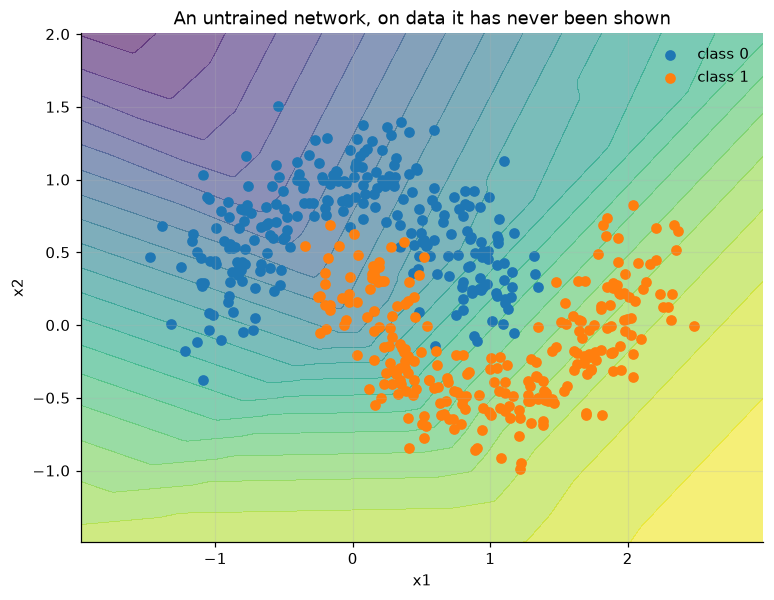

accuracy of the untrained network: 0.736
its outputs span [0.313, 0.907]


In [10]:
# ────────────────────────────────────────────────────────────────────
# 1) torch.meshgrid over torch.linspace ranges for x1 and x2, with a margin so the
#    boundary is not cut off at the edge of the data. 200 points per axis is
#    plenty. Pass indexing="xy" so the grid is laid out the way matplotlib expects.
# 2) Stack the grid into an (n, 2) tensor with .ravel() and torch.column_stack, run
#    forward on it once, then reshape the output back to the grid's shape.
# 3) contourf for the surface, then scatter the real points by class on top.
#    matplotlib accepts CPU tensors directly.
# 4) Wrap it in a function — you will call it again tomorrow on a trained network.
# Search: "torch meshgrid indexing xy matplotlib contourf decision boundary"
# https://pytorch.org/docs/stable/generated/torch.meshgrid.html
#
# ١) `torch.meshgrid` على مدى `torch.linspace` لـ `x1` و`x2` مع هامش كي لا يُقطع الحدّ
#    عند حافة البيانات. ومئتا نقطة لكل محور تكفي. ومرّر `indexing="xy"` لتُرتَّب
#    الشبكة كما تتوقّعها matplotlib.
# ٢) رصّ الشبكة في تنسور `(n, 2)` بـ `.ravel()` و`torch.column_stack`، ومرّرها في
#    `forward` مرة واحدة، ثم أعِد تشكيل المُخرَج إلى شكل الشبكة.
# ٣) `contourf` للسطح، ثم انثر النقاط الحقيقية فوقه مصنّفةً بفئتها. وتقبل matplotlib
#    تنسورات المعالج (CPU) مباشرة.
# ٤) لُفَّها في دالة — فستناديها غدًا على شبكة مُدرَّبة.
# ابحث عن: "torch meshgrid indexing xy matplotlib contourf decision boundary"
# ────────────────────────────────────────────────────────────────────

# TODO: Write plot_boundary(params, title): grid, forward, contourf, scatter.
# مهمة: اكتب `plot_boundary(params, title)`: شبكة نقاط، ثم `forward`، ثم `contourf`، ثم نثر.
def plot_boundary(params, title):
    margin = 0.5

    x1 = torch.linspace(X[:, 0].min() - margin, X[:, 0].max() + margin, 200)
    x2 = torch.linspace(X[:, 1].min() - margin, X[:, 1].max() + margin, 200)

    xx, yy = torch.meshgrid(x1, x2, indexing="xy")
    grid = torch.column_stack((xx.ravel(), yy.ravel()))

    output, _ = forward(params, grid)
    zz = output.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, zz, levels=20, alpha=0.6)

    for cls in [0, 1]:
        mask = y[:, 0] == cls
        plt.scatter(X[mask, 0], X[mask, 1], label=f"class {cls}")

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.legend()
plot_boundary(params, "An untrained network, on data it has never been shown")
plt.show()
untrained_output, _ = forward(params, X)
untrained_accuracy = ((untrained_output > 0.5) == y).double().mean().item()
print(f"accuracy of the untrained network: {untrained_accuracy:.3f}")
print(f"its outputs span [{untrained_output.min():.3f}, "
      f"{untrained_output.max():.3f}]")

**Write one sentence** in the cell below: what does that picture tell you about the 33 numbers in
`params`?

<div dir="rtl" align="right">

**اكتب جملة واحدة** في الخليّة أدناه: ماذا تقول لك تلك الصورة عن الأرقام الثلاثة والثلاثين في
`params`؟

</div>


The 33 parameters are still random, so the network has not learned the pattern in the data yet.

**Your sentence:** _(what the untrained boundary says about the initial weights)_

<div dir="rtl" align="right">

**جملتك:** _(ماذا يقول الحدّ غير المُدرَّب عن الأوزان الابتدائية)_

</div>


The 33 parameters are still random, so the network has not learned the pattern in the data yet.

## Section 3 — Stretch: delete the activations and watch depth vanish  (≈30 min)

Open-ended. Lower expectation of completeness.

Slide 27 claimed that a stack of linear layers with no activation is one linear layer, and proved it
with algebra: `y = W₂(W₁x + b₁) + b₂ = W₂W₁x + (W₂b₁ + b₂) = Wx + b`.

Now measure it. Build a **three**-layer network with no activations anywhere, then collapse it by
hand into a single layer by multiplying the matrices together, and compare the outputs on all 500
rows. Nothing is trained — this is arithmetic, and it should agree to about 1e-15.

Then the honest question in the markdown cell after: you have just built a three-layer network with
1,185 parameters that is exactly equivalent to a three-parameter one. What did the extra 1,182
numbers buy?

<div dir="rtl" align="right">

## القسم الثالث — الإضافي: احذف دوال التنشيط وشاهد العمق يتلاشى (نحو ٣٠ دقيقة)

مفتوح. والتوقّع في الإكمال أقل.

ادّعت الشريحة ٢٧ أن كومة طبقات خطية بلا دالة تنشيط هي طبقة خطية واحدة، وأثبتت ذلك بالجبر:
`y = W₂(W₁x + b₁) + b₂ = W₂W₁x + (W₂b₁ + b₂) = Wx + b`.

وقِسه الآن. ابنِ شبكة من **ثلاث** طبقات بلا أي دالة تنشيط، ثم اطوِها بيدك إلى طبقة واحدة بضرب
المصفوفات بعضها في بعض، وقارن المُخرَجات على الصفوف الخمسمئة كلها. ولا يُدرَّب شيء — فهذا حساب، وينبغي
أن يتوافق إلى نحو 1e-15.

ثم السؤال الصادق في خليّة النصّ بعدها: بنيت الآن شبكة بثلاث طبقات و١٬١٨٥ معاملًا تُكافئ تمامًا شبكة
بثلاثة معاملات. فماذا اشترت الأرقام الـ ١٬١٨٢ الزائدة؟

</div>


In [11]:
# ────────────────────────────────────────────────────────────────────
# 1) Three weight matrices and three biases: (2, 32), (32, 32), (32, 1). No relu
#    and no sigmoid anywhere — just matmul, add, matmul, add, matmul, add.
# 2) Collapse them on paper first, the way slide 24 did: multiply the three
#    weight matrices into one, and push each bias through the layers that come
#    after it before adding them together.
# 3) Compare the two outputs on all 500 rows with (a - b).abs().max().
# Search: "torch matrix product associativity allclose"
# https://pytorch.org/docs/stable/generated/torch.allclose.html
#
# ١) ثلاث مصفوفات أوزان وثلاثة انحيازات: `(2, 32)` و`(32, 32)` و`(32, 1)`. وبلا
#    `relu` وبلا دالة سينية إطلاقًا — ضرب وجمع، ثم ضرب وجمع، ثم ضرب وجمع.
# ٢) اطوِها على الورق أولًا كما فعلت الشريحة ٢٤: اضرب مصفوفات الأوزان الثلاث في
#    مصفوفة واحدة، ومرِّر كل انحياز عبر الطبقات التي تليه
#    قبل أن تجمعها.
# ٣) قارن المُخرَجين على الصفوف الخمسمئة كلها بـ `(a - b).abs().max()`.
# ابحث عن: "torch matrix product associativity allclose"
# ────────────────────────────────────────────────────────────────────

generator = torch.Generator().manual_seed(0)
L1 = torch.normal(0, 0.5, (2, 32), generator=generator)
c1 = torch.normal(0, 0.5, (32,), generator=generator)
L2 = torch.normal(0, 0.5, (32, 32), generator=generator)
c2 = torch.normal(0, 0.5, (32,), generator=generator)
L3 = torch.normal(0, 0.5, (32, 1), generator=generator)
c3 = torch.normal(0, 0.5, (1,), generator=generator)
# TODO: Run X through the three linear layers, with no activation between them.
# مهمة: مرّر `X` في الطبقات الخطية الثلاث بلا دالة تنشيط بينها.
h1 = X @ L1 + c1
h2 = h1 @ L2 + c2
three_layers = h2 @ L3 + c3
# TODO: Collapse the three layers into one weight matrix and one bias, then run X again.
# مهمة: اطوِ الطبقات الثلاث في مصفوفة أوزان واحدة وانحياز واحد، ثم مرّر `X` مرة أخرى.
W_collapsed = L1 @ L2 @ L3
b_collapsed = c1 @ L2 @ L3 + c2 @ L3 + c3

one_layer = X @ W_collapsed + b_collapsed
collapse_error = (three_layers - one_layer).abs().max().item()
n_deep = sum(t.numel() for t in (L1, c1, L2, c2, L3, c3))
n_flat = W_collapsed.numel() + b_collapsed.numel()
print(f"three linear layers: {n_deep:,} parameters, shape "
      f"{tuple(W_collapsed.shape)} once collapsed")
print(f"one linear layer:    {n_flat} parameters")
print(f"largest disagreement over all {len(X)} rows: {collapse_error:.2e}")
print(f"the same function: {collapse_error < 1e-9}")

three linear layers: 1,185 parameters, shape (2, 1) once collapsed
one linear layer:    3 parameters
largest disagreement over all 500 rows: 6.22e-15
the same function: True


**Your paragraph:** _(you built a 1,185-parameter network that is exactly a 3-parameter one. What
did the extra parameters buy, and what would you have to add to make the depth real?)_

<div dir="rtl" align="right">

**فقرتك:** _(بنيت شبكة بـ ١٬١٨٥ معاملًا تُساوي تمامًا شبكة بثلاثة معاملات. فماذا اشترت المعاملات
الزائدة، وما الذي عليك إضافته ليصبح العمق حقيقيًا؟)_

</div>


## Save your artefact

`forward_check.json` — the three hand-verified numbers, the parameter shapes and the parameter
counts.

It is a small file and it does a specific job: tomorrow's lab loads it and confirms that the network
you are about to add a backward pass to is the same network whose forward pass you checked against
the slide. If tomorrow's numbers disagree with this file, the bug is in tomorrow's code, and you will
know that in the first five minutes instead of the last.

<div dir="rtl" align="right">

## احفظ مخرجاتك

`forward_check.json` وفيه الأرقام الثلاثة المُتحقَّق منها يدويًا، وأشكال المعاملات وأعدادها.

وهو ملف صغير يؤدّي عملًا محدّدًا: يُحمّله معمل الغد ويتأكّد أن الشبكة التي أنت على وشك إضافة مرور خلفي
إليها هي الشبكة نفسها التي فحصت مرورها الأمامي مقابل الشريحة. فإن اختلفت أرقام الغد عن هذا الملف
فالعيب في شيفرة الغد، وستعرف ذلك في أول خمس دقائق لا في آخرها.

</div>


In [12]:
forward_check = {
    "lecture_network": {
        "architecture": "2-2-1",
        "input": [1.0, 2.0],
        "hidden_after_relu": [float(v) for v in HAND_A1],
        "logit": HAND_LOGIT,
        "output": HAND_OUTPUT,
        "slide_values": {"hidden": [2.5, 1.0], "logit": 1.5, "output": 0.8176},
    },
    "week_network": {
        "architecture": f"{N_IN}-{N_HIDDEN}-{N_OUT}",
        "seed": SEED,
        "init": "normal(0, sqrt(2 / fan_in)), biases zero",
        "shapes": {name: list(array.shape) for name, array in params.items()},
        "n_weights": int(W_OURS),
        "n_biases": int(B_OURS),
        "untrained_accuracy": float(untrained_accuracy),
    },
    "notes": ("W3D3 loads this and re-checks the forward pass before adding the backward "
              "pass. If the numbers move, the bug is in the new code."),
}

out = ARTEFACT_DIR / "forward_check.json"
out.write_text(json.dumps(forward_check, indent=2), encoding="utf-8")

reloaded = json.loads(out.read_text(encoding="utf-8"))
print(f"Saved {out}")
print(f"hidden layer: {reloaded['lecture_network']['hidden_after_relu']}")
print(f"output:       {reloaded['lecture_network']['output']:.4f}")
print(f"this week's network: {reloaded['week_network']['architecture']}, "
      f"{reloaded['week_network']['n_weights']} weights + "
      f"{reloaded['week_network']['n_biases']} biases")

Saved c:\Users\user\Documents\GitHub\AIEP_Olo_student\week_3_neural_networks\labs\D2_forward_pass\artefacts\forward_check.json
hidden layer: [2.5, 1.0]
output:       0.8176
this week's network: 2-8-1, 24 weights + 9 biases


## Sanity check

Run this last. Every check that fails tells you what to fix and why.

The first two are the ones that matter today: they compare your arithmetic against the slide, to six
and four decimals. Everything tomorrow is built on top of them.

<div dir="rtl" align="right">

## فحص النتائج

شغّل هذه الخليّة أخيرًا. كل فحص يفشل يخبرك بما تُصلحه ولماذا.

والفحصان الأولان هما المهمّان اليوم: يقارنان حسابك بالشريحة إلى ست خانات وأربع خانات عشرية. وكل ما
في الغد مبنيّ عليهما.

</div>


In [13]:
# --- Sanity checks ----------------------------------------------------------------

check(torch.allclose(HAND_A1, torch.tensor([2.5, 1.0]), atol=1e-6),
      f"the hidden layer must produce the slide's [2.5, 1.0] to six decimals, got "
      f"{HAND_A1.round(decimals=6).tolist()}",
      f"يجب أن تُنتج الطبقة المخفية `[2.5, 1.0]` كما في الشريحة إلى ست خانات عشرية، "
      f"والناتج {HAND_A1.round(decimals=6).tolist()}")

check(math.isclose(HAND_LOGIT, 1.5, abs_tol=1e-6)
      and math.isclose(HAND_OUTPUT, 0.8176, abs_tol=5e-5),
      f"the logit must be 1.5 and the output 0.8176 — got {HAND_LOGIT:.6f} and "
      f"{HAND_OUTPUT:.6f}",
      f"يجب أن يكون الـ logit ١٫٥ والمُخرَج ٠٫٨١٧٦ — والناتج {HAND_LOGIT:.6f} و"
      f"{HAND_OUTPUT:.6f}")

shapes_ok = all(params[name].shape == shape for name, shape in expected_shapes.items())
check(shapes_ok and sorted(cache) == ["a1", "z1", "z2"],
      f"every parameter shape must match {expected_shapes} (ok: {shapes_ok}) and forward "
      f"must cache z1, a1 and z2 — it cached {sorted(cache)}",
      f"يجب أن يطابق كل شكل معامل {expected_shapes} (النتيجة {shapes_ok}) وأن تحفظ "
      f"`forward` القيم `z1` و`a1` و`z2` — والمحفوظ {sorted(cache)}")

check(identical and batched.shape == (500, 1),
      f"the batched output must be (500, 1) — it is {tuple(batched.shape)} — and row 0 must "
      f"be bit-identical to the single-row call (identical: {identical})",
      f"يجب أن يكون شكل مُخرَج الدفعة `(500, 1)` — وهو {tuple(batched.shape)} — وأن يكون الصفّ "
      f"صفرًا مطابقًا تمامًا لنداء الصف المفرد (النتيجة {identical})")

clipped = relu(torch.tensor([1.0, -2.0]) @ LECTURE["W1"] + LECTURE["b1"])
check(bool((clipped == 0.0).any()),
      f"ReLU must clip at least one hidden unit to EXACTLY 0.0 for x = [1, -2] — it "
      f"produced {clipped.tolist()}",
      f"يجب أن تقصّ ReLU وحدة مخفية واحدة على الأقل إلى صفر **تامّ** عند `x = [1, -2]` — "
      f"والناتج {clipped.tolist()}")

check(W_OURS + B_OURS == 33 and (W342, B342) == (20, 6),
      f"the 2-8-1 network has 33 parameters (counted {W_OURS + B_OURS}) and the lecture's "
      f"3-4-2 network has 20 weights and 6 biases (counted {W342} and {B342})",
      f"شبكة ٢-٨-١ فيها ٣٣ معاملًا (المعدود {W_OURS + B_OURS}) وشبكة المحاضرة ٣-٤-٢ فيها "
      f"٢٠ وزنًا و٦ انحيازات (المعدود {W342} و{B342})")

check(collapse_error < 1e-9,
      f"three linear layers with no activation must equal one linear layer to 1e-9 — the "
      f"largest disagreement was {collapse_error:.2e}",
      f"يجب أن تساوي ثلاث طبقات خطية بلا تنشيط طبقةً خطية واحدة إلى 1e-9 — وأكبر اختلاف "
      f"كان {collapse_error:.2e}")

check(out.exists() and reloaded["week_network"]["n_weights"] == 24,
      f"forward_check.json must exist and record 24 weights for the 2-8-1 network "
      f"(recorded {reloaded['week_network']['n_weights']})",
      f"يجب أن يوجد `forward_check.json` وأن يسجّل ٢٤ وزنًا لشبكة ٢-٨-١ "
      f"(المسجّل {reloaded['week_network']['n_weights']})")

report()

──────────────────────────────────────────────────────────────────
  ✓  the hidden layer must produce the slide's [2.5, 1.0] to six decimals, got [2.5, 1.0]
  ✓  the logit must be 1.5 and the output 0.8176 — got 1.500000 and 0.817574
  ✓  every parameter shape must match {'W1': (2, 8), 'b1': (8,), 'W2': (8, 1), 'b2': (1,)} (ok: True) and forward must cache z1, a1 and z2 — it cached ['a1', 'z1', 'z2']
  ✓  the batched output must be (500, 1) — it is (500, 1) — and row 0 must be bit-identical to the single-row call (identical: True)
  ✓  ReLU must clip at least one hidden unit to EXACTLY 0.0 for x = [1, -2] — it produced [0.0, 0.0]
  ✓  the 2-8-1 network has 33 parameters (counted 33) and the lecture's 3-4-2 network has 20 weights and 6 biases (counted 20 and 6)
  ✓  three linear layers with no activation must equal one linear layer to 1e-9 — the largest disagreement was 6.22e-15
  ✓  forward_check.json must exist and record 24 weights for the 2-8-1 network (recorded 24)
────────────────

## What's next

You have a machine that computes, and a picture of it computing nothing useful.

Tomorrow (**W3D3**) is the hardest lab of the bootcamp and the one that pays off for the rest of it.
You add the backward pass to this exact network: you measure a gradient by nudging one weight and
dividing, then you let PyTorch's autograd compute all 33 with one `loss.backward()`, and then you
check every one of them against its numerical counterpart. When those two columns agree, you have
proved that the library computes what the lecture derived.

Two things travel with you:

- **`forward_check.json`** — tomorrow's first cell loads it and re-checks `0.8176` before anything
  new is written.
- **Your `forward` returns its cache.** Autograd walks back through `z1`, `a1` and `z2`, and
  because you returned them today, you can look at what it walked through instead of refactoring.

**A3 is issued tomorrow** and is due W4D2. It is a neural-network classification challenge, and its
marks are on your architecture justification and your training curves — not on beating a leaderboard.

<div dir="rtl" align="right">

## ماذا بعد

عندك آلة تحسب، وصورة لها وهي تحسب شيئًا غير مفيد.

وغدًا (**الأسبوع ٣ اليوم ٣**) هو أصعب معامل في المعسكر وأكثرها عائدًا على بقيته. تضيف المرور الخلفي
إلى هذه الشبكة نفسها: تقيس اشتقاقًا بتحريك وزن واحد وبالقسمة، ثم تترك الاشتقاق التلقائي في PyTorch
يحسب الثلاثة والثلاثين كلها بنداء `loss.backward()` واحد، ثم تفحص كل واحد منها مقابل نظيره العددي.
وحين يتوافق العمودان تكون أثبتّ أن المكتبة تحسب ما اشتقّته المحاضرة.

وشيئان يسافران معك:

- **`forward_check.json`** — تُحمّله أول خليّة غدًا وتُعيد فحص `0.8176` قبل كتابة أي شيء جديد.
- **دالة `forward` عندك تُرجع ذاكرتها.** فالاشتقاق التلقائي يرجع عبر `z1` و`a1` و`z2`، ولأنك أرجعتها
  اليوم تستطيع أن تنظر فيما رجع عبره بدل إعادة التشكيل.

**ويُطرح التكليف الثالث غدًا** ويُسلَّم في الأسبوع الرابع اليوم الثاني. وهو تحدّي تصنيف بشبكة عصبية،
ودرجاته على تبرير المعمارية وعلى منحنيات التدريب — لا على تجاوز لوحة صدارة.

</div>
